In [45]:
# System related and data input controls
import os
import warnings
# Ignore the warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# Library
import pandas as pd
import numpy as np
import math
import scipy.stats as stats  # 왜도(Skewness)와 첨도(Kurtosis) 계산을 위해 추가

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score # 평가 지표 추가

# 한글 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

#--------------------------------------------------------------------------

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    precision_recall_curve
)


# 데이터 상세:
| 파일 이름                | Date 단위   | 시작 연월 | 종료 연월   | 컬럼 수 | 행 수 |
|----------------------|-----------|--------|---------|------|-----|
| `df_KTX_monthsum_KK` | 월         | 2015-01| 2025-12 | 22   | 264 |
| `ECON_경제활동인구_KK`     | 월         | 2015-01| 2025-02 | 25   | 122 |
| `ECON_소비자동향조사`       | 월         | 2015-01| 2025-03 | 5    | 123 |
| `ECON_소비자물가지수_KK`    | 월         | 2015-01| 2025-02 | 29   | 122 |
| `KOSIS_내국인출국교통수단별_KK`| 월         | 2015-01| 2024-12 | 5    | 120 |
| `KOSIS_외래객_입국목적별_국적별_KK`| 월         | 2015-01| 2024-12 | 7    | 122 |
| `KOSIS_인구동태건수_및_동태율_추이_출생_사망_혼인_이혼__KK`| 연 | 2015-01| 2024-01 | 13   | 10  |


#### KTX 데이터

In [46]:
RAW_DATA_PATH = '../raw_data/'

## KTX 데이터
df = pd.read_csv(RAW_DATA_PATH + 'df_KTX_monthsum_KK.csv')
df['Date'] = pd.to_datetime(df['Date'])

## 경부선 KTX만 사용
df = df[df['주운행선']=='경부선']


print(f" df -> df_KTX_monthsum : \n {df.columns}\n ")

 df -> df_KTX_monthsum : 
 Index(['전체주중주말', '주운행선', 'Date', '공급차량수', '공급좌석합계수', '승차인원수', '1인당단가', '1인당거리',
       '1좌석당단가', '좌석회전율', '1키로당단가', '승차율', '관광', '일반', '대수송', '임시', '확정',
       '시발역', '종착역', '시발종착역', '열차운행횟수', '1열차당승차인원'],
      dtype='object')
 


#### ECON 데이터

In [47]:
## Econ 데이터
df_active = pd.read_excel(RAW_DATA_PATH + 'ECON_경제활동인구_KK.xlsx', sheet_name='데이터', header=7)
df_active['Date'] = pd.to_datetime(df_active['Date'])
df_sentiment = pd.read_excel(RAW_DATA_PATH + 'ECON_소비자동향조사(전국, 월, 2008.9~)_KK.xlsx', sheet_name='데이터', header=7)
df_sentiment['Date'] = pd.to_datetime(df_sentiment['Date'])
df_sentiment = df_sentiment.dropna(axis=1)
df_price = pd.read_excel(RAW_DATA_PATH + 'ECON_소비자물가지수_KK.xlsx', sheet_name='데이터', header=6)
df_price['Date'] = pd.to_datetime(df_price['Date'])
df_price.columns = df_price.columns.str.strip()  # 컬럼에 공백이 있음

print(f" df_active -> ECON_경제활동인구 : \n {df_active.columns}\n ")
print(f" df_sentiment -> ECON_소비자동향조사(전국, 월, 2008.9~) : \n {df_sentiment.columns}\n ")
print(f" df_price -> ECON_소비자물가지수 : \n {df_price.columns}\n ")

 df_active -> ECON_경제활동인구 : 
 Index(['Date', '경제활동인구_원자료', '경제활동인구_전기대비증감', '경제활동인구_전년동기대비증감',
       '경제활동인구_이동평균(3기간)', '  실업률_원자료', '  실업률_전기대비증감', '  실업률_전년동기대비증감',
       '  실업률_이동평균(3기간)', '15세이상인구_원자료', '15세이상인구_전기대비증감', '15세이상인구_전년동기대비증감',
       '15세이상인구_이동평균(3기간)', '비경제활동인구_원자료', '비경제활동인구_전기대비증감',
       '비경제활동인구_전년동기대비증감', '비경제활동인구_이동평균(3기간)', '경제활동참가율_원자료',
       '경제활동참가율_전기대비증감', '경제활동참가율_전년동기대비증감', '경제활동참가율_이동평균(3기간)', '고용률_원자료',
       '고용률_전기대비증감', '고용률_전년동기대비증감', '고용률_이동평균(3기간)'],
      dtype='object')
 
 df_sentiment -> ECON_소비자동향조사(전국, 월, 2008.9~) : 
 Index(['Date', '소비자심리지수_원자료', '소비자심리지수_전기대비증감', '소비자심리지수_전년동기대비증감',
       '소비자심리지수_이동평균(3기간)'],
      dtype='object')
 
 df_price -> ECON_소비자물가지수 : 
 Index(['Date', '총지수_원자료', '총지수_전기대비증감', '총지수_전년동기대비증감', '총지수_이동평균(3기간)',
       '운송장비_원자료', '운송장비_전기대비증감', '운송장비_전년동기대비증감', '운송장비_이동평균(3기간)',
       '개인운송장비 운영_원자료', '개인운송장비 운영_전기대비증감', '개인운송장비 운영_전년동기대비증감',
       '개인운송장비 운영_이동평균(3기간)', '철도 여객수송_원자료', '철도 여객수송_전기대비증감',


In [48]:
## Kosis 데이터
df_traffic = pd.read_csv(RAW_DATA_PATH + 'KOSIS_내국인출국교통수단별_KK.csv', encoding='cp949', header=2)
df_traffic['Date'] = pd.to_datetime(df_traffic['Date'])
df_traffic['내국인출입국_공항'] = df_traffic[[col for col in df_traffic.columns if col.split('_')[0] == '공항']].sum(axis=1).values
df_traffic['내국인출입국_항구'] = df_traffic[[col for col in df_traffic.columns if col.split('_')[0] == '항구']].sum(axis=1).values
df_traffic.drop(columns=[col for col in df_traffic.columns if col.split('_')[0] in ['공항', '항구']], inplace=True)
df_entry = pd.read_csv(RAW_DATA_PATH + 'KOSIS_외래객_입국목적별_국적별_KK.csv', encoding='cp949', header=1)
df_entry['Date'] = pd.to_datetime(df_entry['Date'])
df_population = pd.read_csv(RAW_DATA_PATH + 'KOSIS_인구동태건수_및_동태율_추이_출생_사망_혼인_이혼__KK.csv', encoding='cp949', header=0)
df_population['Date'] = pd.to_datetime(df_population['Date'], format='%Y', errors='coerce')
df_population = df_population[[col for col in df_population.columns if col not in ['영아사망률(출생아 천명당)', '기대수명(출생시 기대여명)',
                                                                                   '기대수명(출생시 기대여명) - 남', '기대수명(출생시 기대여명) - 여']]]

print(f" df_traffic -> KOSIS_내국인출국교통수단별 : \n {df_traffic.columns}\n ")
print(f" df_entry -> KOSIS_외래객_입국목적별_국적별 : \n {df_entry.columns}\n ")
print(f" df_population -> KOSIS_인구동태건수_및_동태율_추이_출생_사망_혼인_이혼 : \n {df_population.columns}\n ")

 df_traffic -> KOSIS_내국인출국교통수단별 : 
 Index(['Date', '내국인출입국_전체', '내국인출입국_공항', '내국인출입국_항구'], dtype='object')
 
 df_entry -> KOSIS_외래객_입국목적별_국적별 : 
 Index(['Date', '외래객입국사유_전체', '외래객입국사유_관광', '외래객입국사유_상용', '외래객입국사유_공융',
       '외래객입국사유_유학연수', '외래객입국사유_기타'],
      dtype='object')
 
 df_population -> KOSIS_인구동태건수_및_동태율_추이_출생_사망_혼인_이혼 : 
 Index(['Date', '출생아수(명)', '사망자수(명)', '자연증가건수(명)', '조출생률(천명당)', '조사망률(천명당)',
       '자연증가율(천명당)', '합계출산율(명)', '출생성비(명)', '혼인건수(건)', '조혼인율(천명당)', '이혼건수(건)',
       '조이혼율(천명당)'],
      dtype='object')
 


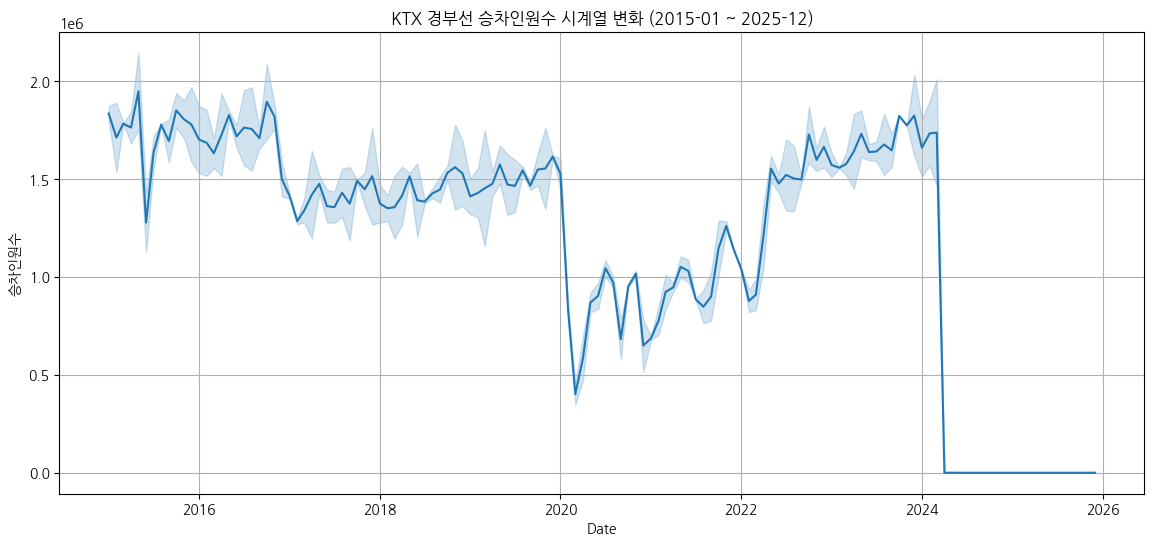

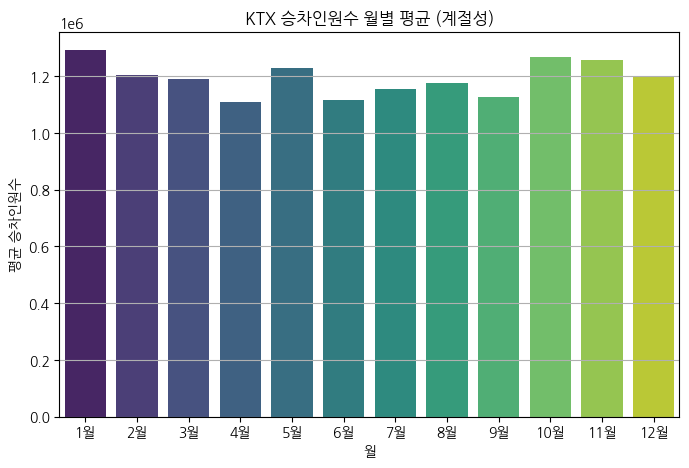

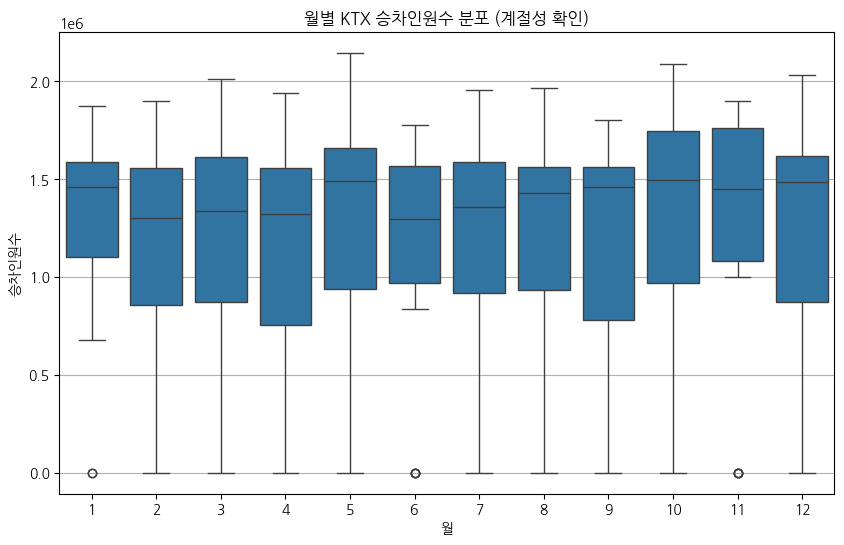

### KTX 승차인원수 주요 통계량 ###
count    2.640000e+02
mean     1.193699e+06
std      6.135753e+05
min      0.000000e+00
25%      9.211645e+05
50%      1.427504e+06
75%      1.617264e+06
max      2.144330e+06
Name: 승차인원수, dtype: float64


In [49]:
# 시계열 시각화
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Date', y='승차인원수')
plt.title('KTX 경부선 승차인원수 시계열 변화 (2015-01 ~ 2025-12)')
plt.xlabel('Date')
plt.ylabel('승차인원수')
plt.grid(True)
plt.show()

# 월별 평균 승차인원수 (계절성 확인)
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['승차인원수'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='viridis')
plt.title('KTX 승차인원수 월별 평균 (계절성)')
plt.xlabel('월')
plt.ylabel('평균 승차인원수')
plt.xticks(range(12), ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월'])
plt.grid(axis='y')
plt.show()

# 월별 승차인원 상자 그림 (계절성 분석)
df['Month'] = df['Date'].dt.month

plt.figure(figsize=(10, 6))
sns.boxplot(x='Month', y='승차인원수', data=df)
plt.title('월별 KTX 승차인원수 분포 (계절성 확인)')
plt.xlabel('월')
plt.ylabel('승차인원수')
plt.grid(axis='y')
plt.show()

# KTX 수요 주요 통계량
print("### KTX 승차인원수 주요 통계량 ###")
print(df['승차인원수'].describe())

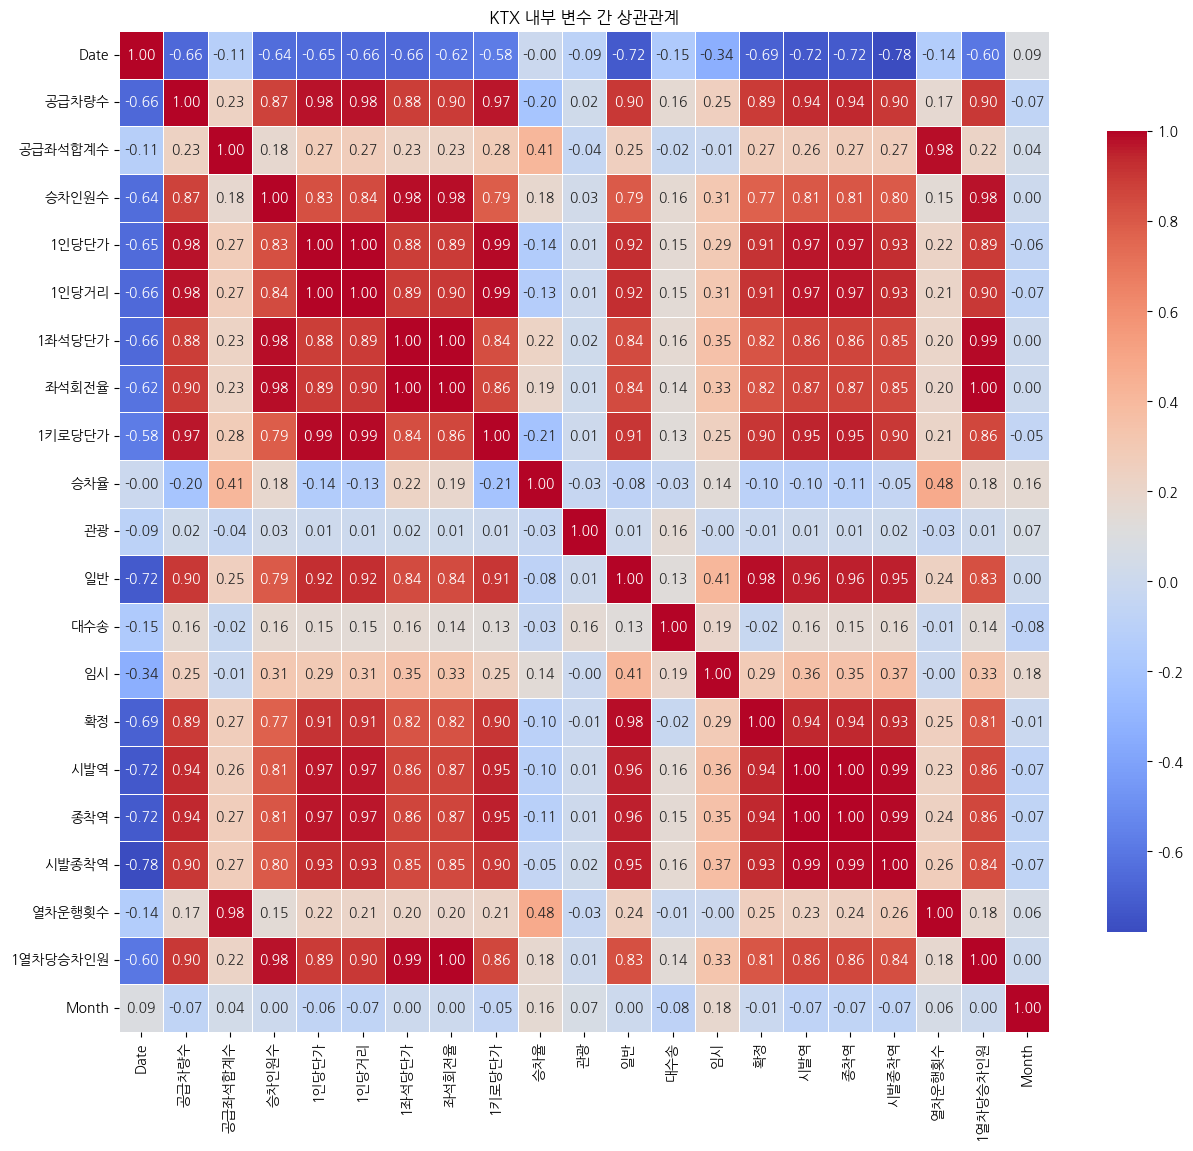

In [50]:
# KTX 내부 주요 변수들 선택
corr_matrix_ktx = df.drop(['전체주중주말', '주운행선'], axis=1).corr()

plt.figure(figsize=(15, 13))
sns.heatmap(corr_matrix_ktx, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'shrink': 0.8})
plt.title('KTX 내부 변수 간 상관관계')
plt.show()

In [51]:
df_merged = df.copy()

# 1. 경제 활동 인구 (df_active) 병합
# '  실업률_원자료' 등에도 공백이 있으므로 병합 전에 컬럼 정리 필요
df_active.columns = df_active.columns.str.strip().str.replace(' ', '_', regex=False)
df_merged = df_merged.merge(df_active, on='Date', how='left')

# 2. 소비자 심리 (df_sentiment) 병합
df_merged = df_merged.merge(df_sentiment, on='Date', how='left')

# 3. 소비자 물가지수 (df_price) 병합 - 이미 컬럼 정리 완료됨
# 정리된 컬럼 이름: '총지수_원자료', '철도 여객수송_원자료', '도로 여객수송_원자료' (공백을 언더바로 바꾸지 않았다면)
# 현재 컬럼명을 다시 확인하여 공백을 처리합니다.
df_price.columns = df_price.columns.str.strip()
df_price.columns = df_price.columns.str.replace(' ', '_', regex=False) # 언더바로 대체하여 통일
df_merged = df_merged.merge(df_price, on='Date', how='left')

# 4. 내국인 출국 (df_traffic) 병합
df_merged = df_merged.merge(df_traffic, on='Date', how='left')

# 5. 외래객 입국 (df_entry) 병합
df_merged = df_merged.merge(df_entry, on='Date', how='left')

# 병합 결과 확인
print("✅ 데이터프레임 최종 병합 후 상위 5개 행:")
print(df_merged.head())
print("\n✅병합된 데이터프레임의 결측치(NaN) 개수:")
print(df_merged.isnull().sum())
print("\n✅병합된 데이터프레임의 컬럼 개수:")
print(len(df_merged.columns))

✅ 데이터프레임 최종 병합 후 상위 5개 행:
  전체주중주말 주운행선       Date  공급차량수  공급좌석합계수    승차인원수          1인당단가  \
0     주말  경부선 2015-01-01  34020  1741181  1871129  496684.493797   
1     주말  경부선 2015-02-01  28992  1488544  1533571  434612.946125   
2     주말  경부선 2015-03-01  31246  1607627  1780862  454810.916585   
3     주말  경부선 2015-04-01  28848  1491483  1681821  424444.354602   
4     주말  경부선 2015-05-01  36102  1863967  2144330  531982.093900   

          1인당거리         1좌석당단가      좌석회전율  ...  기타_여객운송_이동평균(3기간)  내국인출입국_전체  \
0  37822.859888  533787.092457  15.054794  ...               90.7  1834538.0   
1  32762.087399  447295.799500  12.361342  ...               91.3  1445609.0   
2  34157.906870  503277.605271  14.399538  ...               91.6  1416683.0   
3  31774.297786  478264.495853  13.528454  ...               91.5  1495460.0   
4  40218.497239  611756.680000  17.251379  ...               91.4  1579265.0   

   내국인출입국_공항  내국인출입국_항구  외래객입국사유_전체  외래객입국사유_관광  외래객입국사유_상용  외래객입국사유_공융  \
0  175250

In [52]:
# df_KTX_monthsum_KK에 Year, Month 컬럼 추가
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# 1. 시계열 모델링을 위한 기본 변수 생성
df_merged['Year'] = df_merged['Date'].dt.year
df_merged['Month'] = df_merged['Date'].dt.month

In [ ]:
# KOSIS_인구동태건수_및_동태율_추이 (df_population) 컬럼 정리
#  Index(['Date', '출생아수(명)', '사망자수(명)', '자연증가건수(명)', '조출생률(천명당)', '조사망률(천명당)',
#        '자연증가율(천명당)', '합계출산율(명)', '출생성비(명)', '혼인건수(건)', '조혼인율(천명당)', '이혼건수(건)',
#        '조이혼율(천명당)']
df_population.columns = df_population.columns.str.strip().str.replace('(', '_', regex=False).str.replace(')', '', regex=False)

# 연 단위 데이터를 월 단위 데이터에 매핑
df_population['Year'] = df_population['Date'].dt.year

# 월 평균 지표 계산 (연간 데이터를 12개월로 나눔)
# 연간 건수를 월평균으로 변환
df_population_monthly = df_population.copy()
df_population_monthly['출생아수_월평균_명'] = df_population_monthly['출생아수_명'] / 12
df_population_monthly['사망자수_월평균_명'] = df_population_monthly['사망자수_명'] / 12
df_population_monthly['자연증가건수_월평균_명'] = df_population_monthly['자연증가건수_명'] / 12
df_population_monthly['혼인건수_월평균_건'] = df_population_monthly['혼인건수_건'] / 12
df_population_monthly['이혼건수_월평균_건'] = df_population_monthly['이혼건수_건'] / 12

# 비율 지표는 그대로 사용 (이미 비율이므로 월평균 변환 불필요)
# 조출생률_천명당, 조사망률_천명당, 자연증가율_천명당, 합계출산율_명, 출생성비_명, 조혼인율_천명당, 조이혼율_천명당

# Year를 기준으로 df_merged에 병합할 컬럼 선택
population_cols_to_merge = ['Year', '출생아수_월평균_명', '사망자수_월평균_명', '자연증가건수_월평균_명',
                             '혼인건수_월평균_건', '이혼건수_월평균_건',
                             '조출생률_천명당', '조사망률_천명당', '자연증가율_천명당',
                             '합계출산율_명', '출생성비_명', '조혼인율_천명당', '조이혼율_천명당']

df_population_for_merge = df_population_monthly[population_cols_to_merge]

# Year를 기준으로 df_merged에 병합
df_merged = df_merged.merge(df_population_for_merge, on='Year', how='left')

print("\n✅ 인구 데이터 병합 후 데이터 확인:")
print(df_merged[['Date', 'Year', 'Month', '승차인원수', '출생아수_월평균_명', '혼인건수_월평균_건', '조출생률_천명당']].head())
print("\n✅ 병합된 데이터프레임의 컬럼 개수:")
print(len(df_merged.columns))
print("\n✅ 인구 관련 컬럼 결측치 확인:") ## --> 24년도부터 없음
print(df_merged[population_cols_to_merge].isnull().sum())


✅ 인구 데이터 병합 후 데이터 확인:
        Date  Year  Month    승차인원수  출생아수_월평균_명    혼인건수_월평균_건  조출생률_천명당
0 2015-01-01  2015      1  1871129     36535.0  25235.666667       8.6
1 2015-02-01  2015      2  1533571     36535.0  25235.666667       8.6
2 2015-03-01  2015      3  1780862     36535.0  25235.666667       8.6
3 2015-04-01  2015      4  1681821     36535.0  25235.666667       8.6
4 2015-05-01  2015      5  2144330     36535.0  25235.666667       8.6

✅ 병합된 데이터프레임의 컬럼 개수:
101

✅ 인구 관련 컬럼 결측치 확인:
Year             0
출생아수_월평균_명      24
사망자수_월평균_명      24
자연증가건수_월평균_명    24
혼인건수_월평균_건      24
이혼건수_월평균_건      24
조출생률_천명당        24
조사망률_천명당        24
자연증가율_천명당       24
합계출산율_명         24
출생성비_명          24
조혼인율_천명당        24
조이혼율_천명당        24
dtype: int64


### 주말 수, 코로나 변수, 공휴일 수, 이동평균 추가

In [ ]:
# 1. 코로나 기간 더미 변수 (2020년 1월 ~ 2022년 4월)
df_merged['코로나기간'] = ((df_merged['Date'] >= '2020-01-01') & 
                          (df_merged['Date'] <= '2022-04-30')).astype(int)

# 2. 주말 수 계산 (해당 월의 토요일 + 일요일 개수)
def count_weekends(date):
    """해당 월의 주말(토,일) 일수 계산"""
    year = date.year
    month = date.month
    # 해당 월의 모든 날짜 생성
    days_in_month = pd.date_range(start=f'{year}-{month:02d}-01', 
                                    periods=pd.Period(f'{year}-{month:02d}').days_in_month, 
                                    freq='D')
    # 토요일(5), 일요일(6) 개수 세기
    weekend_count = sum(day.dayofweek in [5, 6] for day in days_in_month)
    return weekend_count

df_merged['주말수'] = df_merged['Date'].apply(count_weekends)

# 3. 공휴일 수 계산 (holidays 라이브러리 사용)
import holidays

# 한국 공휴일 객체 생성
kr_holidays = holidays.KR()

def count_holidays(date):
    """해당 월의 공휴일 수 계산 (holidays 라이브러리 사용)"""
    year = date.year
    month = date.month
    
    # 해당 월의 모든 날짜 생성
    days_in_month = pd.date_range(start=f'{year}-{month:02d}-01', 
                                    periods=pd.Period(f'{year}-{month:02d}').days_in_month, 
                                    freq='D')
    
    # 공휴일 개수 세기 (주말 제외)
    holiday_count = 0
    for day in days_in_month:
        # 공휴일이면서 주말이 아닌 경우만 카운트
        if day in kr_holidays and day.dayofweek < 5:  # 월~금(0~4)만 카운트
            holiday_count += 1
    
    return holiday_count

df_merged['공휴일수'] = df_merged['Date'].apply(count_holidays)

# 4. Lag 변수 (이전 달 승차인원수) - Data Leakage 방지: 이전 시점만 사용
df_merged['승차인원수_lag1'] = df_merged['승차인원수'].shift(1)  # 1개월 전
df_merged['승차인원수_lag2'] = df_merged['승차인원수'].shift(2)  # 2개월 전
df_merged['승차인원수_lag3'] = df_merged['승차인원수'].shift(3)  # 3개월 전
df_merged['승차인원수_lag12'] = df_merged['승차인원수'].shift(12)  # 12개월 전 (작년 동월)

# 5. Rolling 통계 (Backward-looking only) - Data Leakage 방지
# shift(1)을 사용하여 현재 시점을 제외하고 이전 데이터만 사용
df_merged['승차인원수_rolling_mean_3m'] = df_merged['승차인원수'].shift(1).rolling(window=3, min_periods=1).mean()
df_merged['승차인원수_rolling_std_3m'] = df_merged['승차인원수'].shift(1).rolling(window=3, min_periods=1).std()

# 6. 전월 대비 증감률 계산
df_merged['승차인원수_전월대비증감률'] = df_merged['승차인원수'].pct_change(1) * 100

print("✅ Feature Engineering 완료!")
print(f"\n생성된 피처:")
print(f"- 코로나기간 (더미 변수)")
print(f"- 주말수 (해당 월의 토,일 개수)")
print(f"- 공휴일수 (holidays 라이브러리 사용, 설날/추석 등 음력 공휴일 자동 계산)")
print(f"- 승차인원수 Lag 변수 (1, 2, 3, 12개월 전)")
print(f"- Rolling 통계 (3개월 이동평균/표준편차, backward-looking)")
print(f"- 전월 대비 증감률")

print(f"\n✅ Feature Engineering 후 데이터 확인:")
print(df_merged[['Date', 'Year', 'Month', '승차인원수', '코로나기간', '주말수', '공휴일수', 
                    '승차인원수_lag1', '승차인원수_lag12', '승차인원수_rolling_mean_3m']].head(15))

print(f"\n✅ 최종 컬럼 개수: {len(df_merged.columns)}")

✅ Feature Engineering 완료!

생성된 피처:
- 코로나기간 (더미 변수)
- 주말수 (해당 월의 토,일 개수)
- 공휴일수 (holidays 라이브러리 사용, 설날/추석 등 음력 공휴일 자동 계산)
- 승차인원수 Lag 변수 (1, 2, 3, 12개월 전)
- Rolling 통계 (3개월 이동평균/표준편차, backward-looking)
- 전월 대비 증감률

✅ Feature Engineering 후 데이터 확인:
         Date  Year  Month    승차인원수  코로나기간  주말수  공휴일수  승차인원수_lag1  \
0  2015-01-01  2015      1  1871129      0    9     1         NaN   
1  2015-02-01  2015      2  1533571      0    8     3   1871129.0   
2  2015-03-01  2015      3  1780862      0    9     0   1533571.0   
3  2015-04-01  2015      4  1681821      0    8     0   1780862.0   
4  2015-05-01  2015      5  2144330      0   10     2   1681821.0   
5  2015-06-01  2015      6  1125689      0    8     0   2144330.0   
6  2015-07-01  2015      7  1549797      0    8     0   1125689.0   
7  2015-08-01  2015      8  1773664      0   10     1   1549797.0   
8  2015-09-01  2015      9  1585350      0    8     2   1773664.0   
9  2015-10-01  2015     10  1939094      0    9     1   1585350.

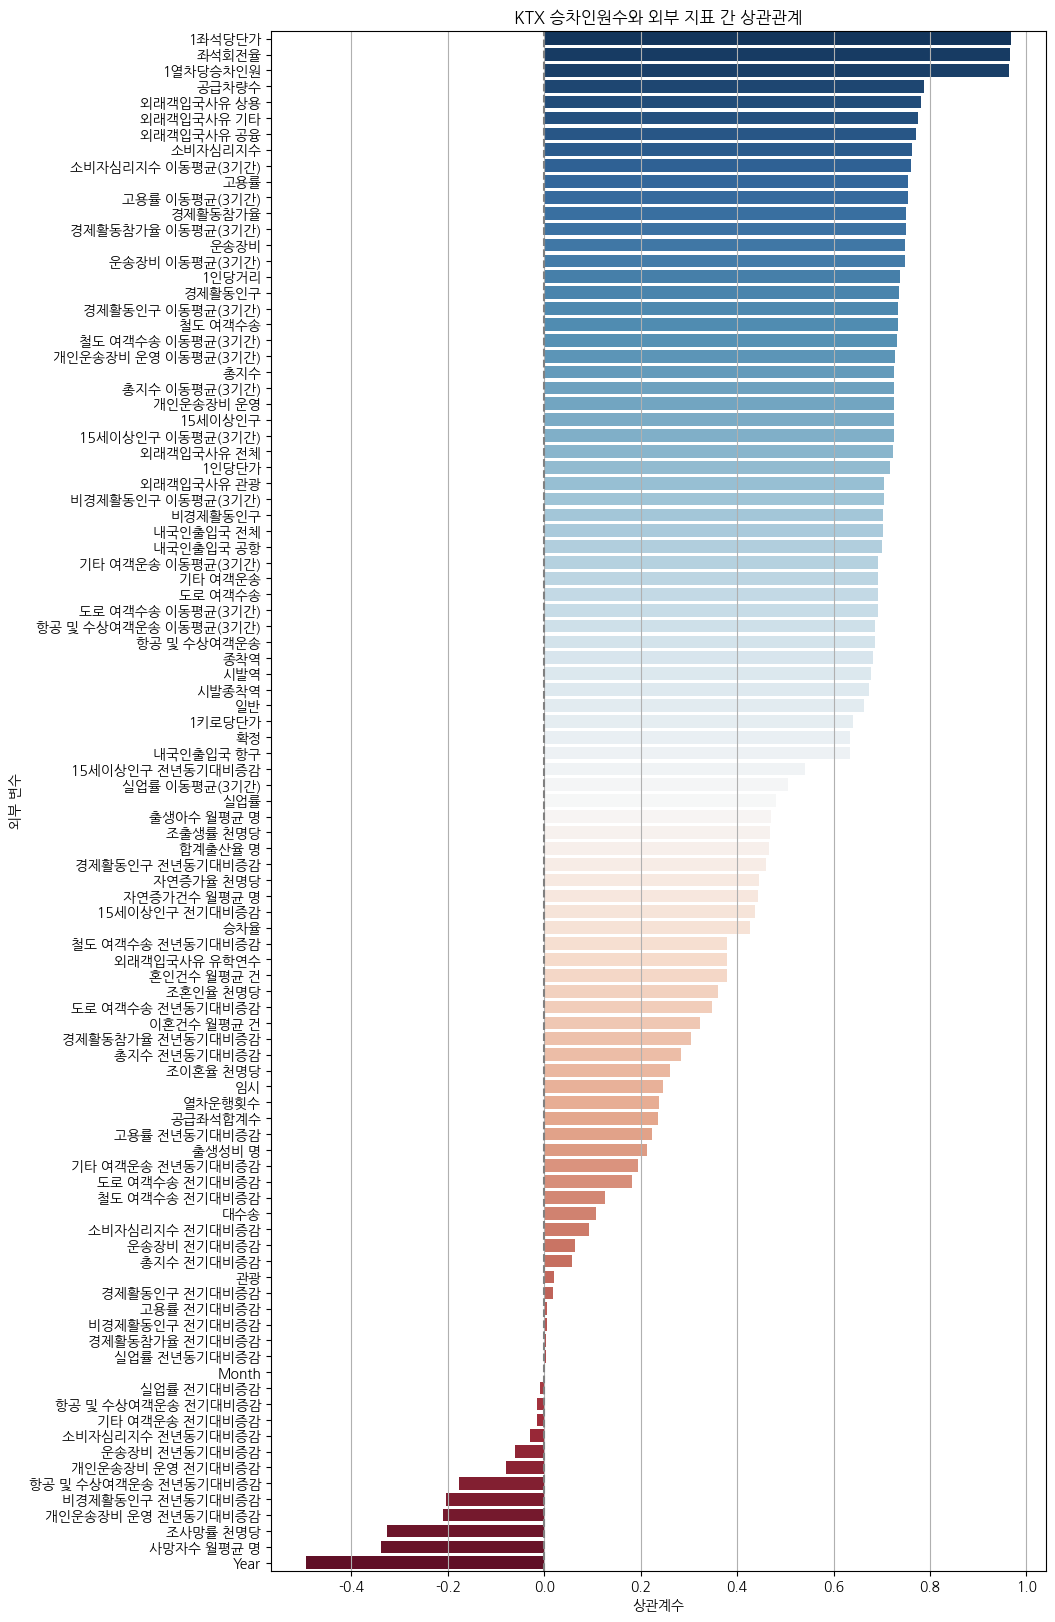

In [56]:
# KTX 수요와 외부 변수 간 상관관계 분석을 위한 컬럼 선택
external_cols = list(df_merged.drop(['전체주중주말', '주운행선', 'Date'], axis=1).columns)

# 결측치 제거 후 상관관계 계산 (기간 불일치로 인한 NaN 제거)
df_corr = df_merged[external_cols].dropna()

# 상관관계 행렬 계산
corr_matrix_external = df_corr.corr()

# '승차인원수'와의 상관계수만 추출
correlation_with_demand = corr_matrix_external['승차인원수'].sort_values(ascending=False).drop('승차인원수')

plt.figure(figsize=(10, 20))
sns.barplot(x=correlation_with_demand.values, y=correlation_with_demand.index.str.replace('_원자료', '').str.replace('_', ' '), palette='RdBu_r')
plt.title('KTX 승차인원수와 외부 지표 간 상관관계')
plt.xlabel('상관계수')
plt.ylabel('외부 변수')
plt.axvline(0, color='grey', linestyle='--')
plt.grid(axis='x')
plt.show()

### 시계열 분해 (Seasonal Decomposition)??

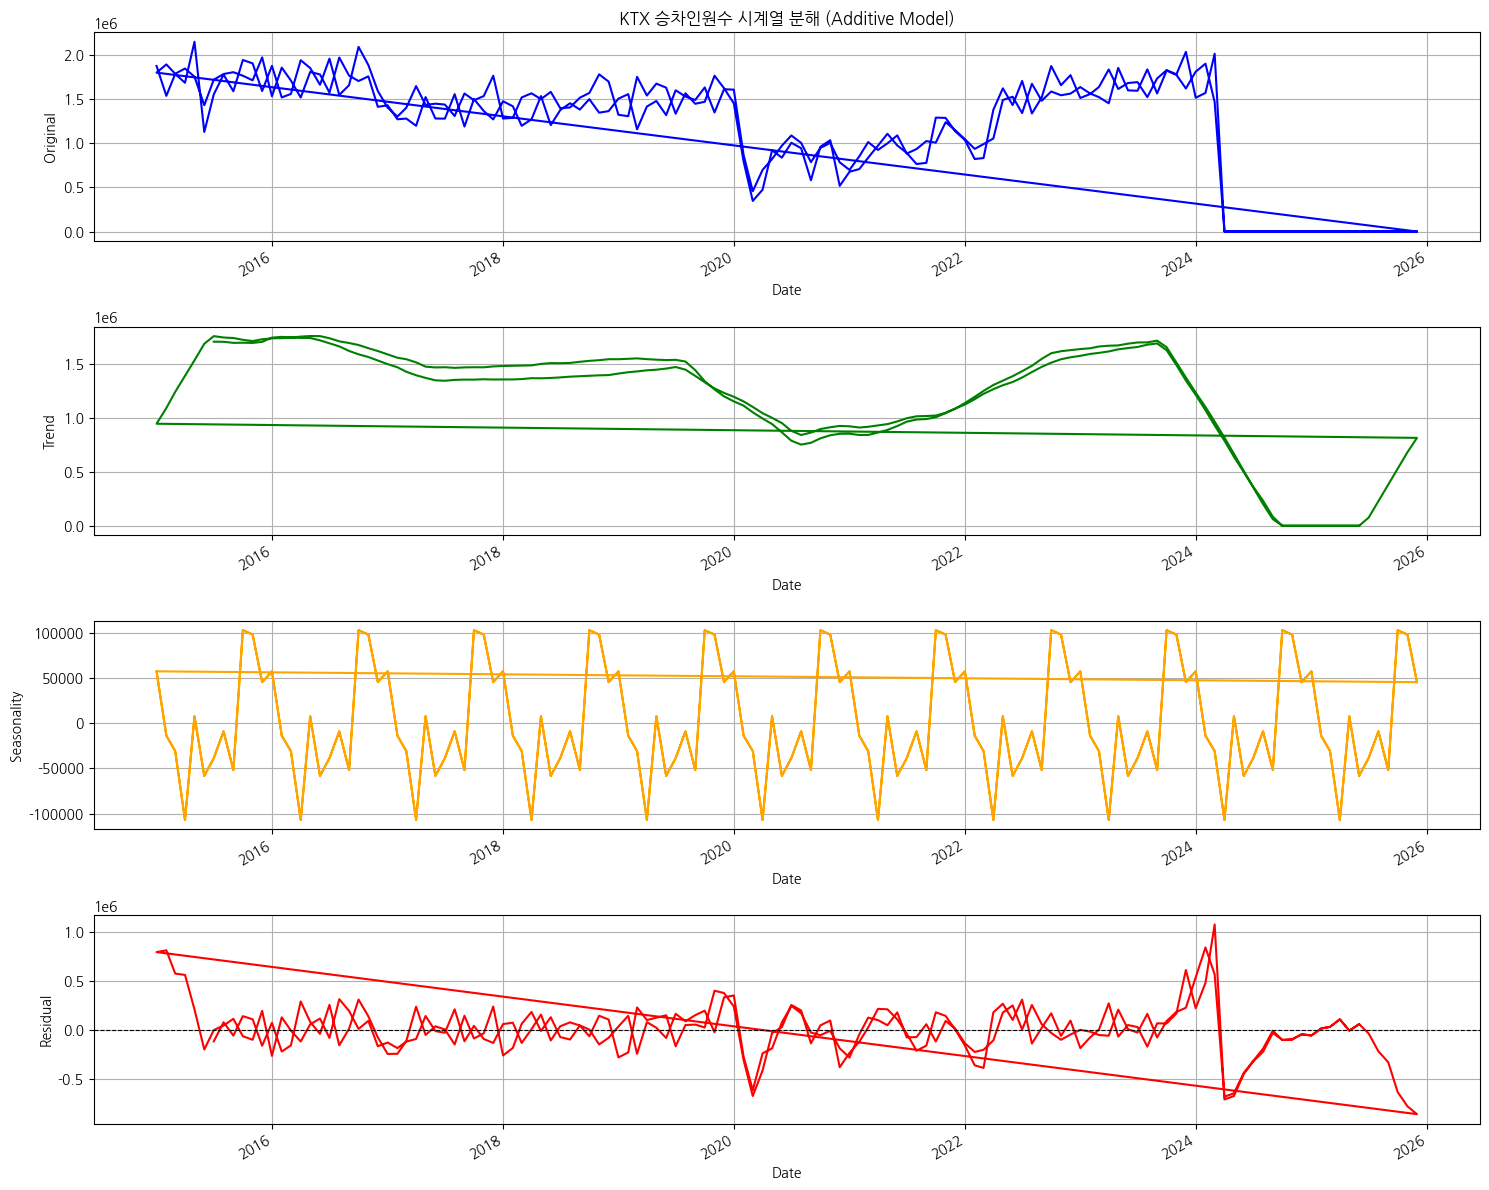

### 잔차(Residual) 통계량 ###
count    2.520000e+02
mean     3.741124e+02
std      2.502268e+05
min     -8.598358e+05
25%     -1.179494e+05
50%      3.858302e+03
75%      1.255264e+05
max      1.075291e+06
Name: resid, dtype: float64

### 잔차 절댓값 상위 10개 (이상치 확인) ###
Date
2024-03-01    1.075291e+06
2025-12-01    8.598358e+05
2024-02-01    8.403430e+05
2015-02-01    8.114657e+05
2015-01-01    7.933346e+05
2025-11-01    7.800108e+05
2024-04-01    7.101683e+05
2024-04-01    6.816833e+05
2024-05-01    6.747768e+05
2020-03-01    6.744562e+05
Name: resid, dtype: float64


In [61]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 분해를 위한 데이터 준비 (결측치 제거)
df_decompose = df_merged[['Date', '승차인원수']].set_index('Date').dropna()

# 시계열 분해 (additive model)
decomposition = seasonal_decompose(df_decompose['승차인원수'], model='additive', period=12)

# 시각화
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# 원본 데이터
decomposition.observed.plot(ax=axes[0], color='blue')
axes[0].set_ylabel('Original')
axes[0].set_title('KTX 승차인원수 시계열 분해 (Additive Model)')
axes[0].grid(True)

# 트렌드
decomposition.trend.plot(ax=axes[1], color='green')
axes[1].set_ylabel('Trend')
axes[1].grid(True)

# 계절성
decomposition.seasonal.plot(ax=axes[2], color='orange')
axes[2].set_ylabel('Seasonality')
axes[2].grid(True)

# 잔차 (이상치 확인)
decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_ylabel('Residual')
axes[3].axhline(0, linestyle='--', color='black', linewidth=0.8)
axes[3].grid(True)

plt.tight_layout()
plt.show()

# 잔차 통계 - 코로나 등 이상치 확인
print("### 잔차(Residual) 통계량 ###")
print(decomposition.resid.describe())
print("\n### 잔차 절댓값 상위 10개 (이상치 확인) ###")
residual_abs = decomposition.resid.abs().sort_values(ascending=False)
print(residual_abs.head(10))

### 4. Feature Engineering - 시계열 특성 및 외부 변수

In [62]:
len(df_merged.columns)

111

### 5. 타겟 변수(승차인원수) 분포 분석

In [ ]:
from scipy import stats

# 결측치 제거
target_data = df_features['승차인원수'].dropna()

# 1. 히스토그램 및 정규분포 곡선
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 원본 분포
axes[0].hist(target_data, bins=30, color='skyblue', edgecolor='black', density=True, alpha=0.7)
axes[0].set_title('승차인원수 분포 (원본)')
axes[0].set_xlabel('승차인원수')
axes[0].set_ylabel('밀도')
axes[0].grid(axis='y', alpha=0.5)

# 정규분포 곡선 추가
mu, std = target_data.mean(), target_data.std()
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axes[0].plot(x, p, 'r--', linewidth=2, label='정규분포')
axes[0].legend()

# Q-Q Plot (정규성 검정)
stats.probplot(target_data, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (정규성 확인)')
axes[1].grid(True)

# 로그 변환 분포
log_target = np.log1p(target_data)  # log(1+x) 변환
axes[2].hist(log_target, bins=30, color='lightgreen', edgecolor='black', density=True, alpha=0.7)
axes[2].set_title('승차인원수 분포 (로그 변환)')
axes[2].set_xlabel('log(1 + 승차인원수)')
axes[2].set_ylabel('밀도')
axes[2].grid(axis='y', alpha=0.5)

# 로그 변환 정규분포 곡선
mu_log, std_log = log_target.mean(), log_target.std()
xmin_log, xmax_log = axes[2].get_xlim()
x_log = np.linspace(xmin_log, xmax_log, 100)
p_log = stats.norm.pdf(x_log, mu_log, std_log)
axes[2].plot(x_log, p_log, 'r--', linewidth=2, label='정규분포')
axes[2].legend()

plt.tight_layout()
plt.show()

# 2. 통계적 검정
print("### 타겟 변수 (승차인원수) 기술통계량 ###")
print(target_data.describe())
print(f"\n평균: {target_data.mean():,.0f}")
print(f"중앙값: {target_data.median():,.0f}")
print(f"표준편차: {target_data.std():,.0f}")
print(f"왜도(Skewness): {target_data.skew():.3f}")
print(f"첨도(Kurtosis): {target_data.kurtosis():.3f}")

# 정규성 검정 (Shapiro-Wilk Test)
shapiro_stat, shapiro_p = stats.shapiro(target_data)
print(f"\n### Shapiro-Wilk 정규성 검정 ###")
print(f"검정 통계량: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("결론: 정규분포를 따름 (p > 0.05)")
else:
    print("결론: 정규분포를 따르지 않음 (p < 0.05)")

# 로그 변환 후 정규성 검정
shapiro_stat_log, shapiro_p_log = stats.shapiro(log_target)
print(f"\n### 로그 변환 후 Shapiro-Wilk 정규성 검정 ###")
print(f"검정 통계량: {shapiro_stat_log:.4f}")
print(f"p-value: {shapiro_p_log:.4f}")
if shapiro_p_log > 0.05:
    print("결론: 정규분포를 따름 (p > 0.05)")
else:
    print("결론: 정규분포를 따르지 않음 (p < 0.05)")

print(f"\n왜도(Skewness) - 원본: {target_data.skew():.3f}, 로그 변환: {log_target.skew():.3f}")
print(f"첨도(Kurtosis) - 원본: {target_data.kurtosis():.3f}, 로그 변환: {log_target.kurtosis():.3f}")

print("\n💡 모델링 제안:")
if abs(log_target.skew()) < abs(target_data.skew()):
    print("→ 로그 변환 후 왜도가 감소했으므로, 모델링 시 로그 변환 고려 권장")
else:
    print("→ 원본 데이터 사용 권장")